<a href="https://colab.research.google.com/github/Khushibung05/RNN/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive/')

# Path to the dataset (update if needed)
path = '/content/drive/My Drive/Colab Notebooks/optimized_waste_management_data.csv'

# Importing the dataset
data= pd.read_csv(path)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=data.fillna(method='ffill')

/tmp/ipykernel_243/613671637.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data=data.fillna(method='ffill')


In [ ]:
#extract feature to predict
#use only waste column for forecasting
waste_data=data[['waste_volume']]

**Normalize data**
neural networks work better when data values are scaled between 0 and 1

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(waste_data)

**convert data into sequences**

RNN requires sequential input

Ex: previous 10 days -> Predict next day

In [ ]:
def create_sequences(data, seq_length):
  x=[]
  y=[]
  for i in range(len(data)-seq_length):
    x.append(data[i:(i+seq_length)])
    y.append(data[i+seq_length])
  return np.array(x), np.array(y)

**create time sequences**

In [ ]:
sequence_length=10
x,y=create_sequences(scaled_data,sequence_length)

print(x.shape)
print(y.shape)

(1451, 10, 1)
(1451, 1)


**Build the RNN Model**

Architecture:

input->RNN Layer->Dense output

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
model=Sequential()
model.add(SimpleRNN(50,activation='tanh',input_shape=(sequence_length,1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compile the Model**

In [ ]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

train-test-split

In [ ]:
split=int(0.8*len(x))
x_train=x[:split]
x_test=x[split:]
y_train=y[:split]
y_test=y[split:]

**TRain the Model**
we train the model for 50 epochs

In [ ]:
history=model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

#epoch=50
#model sees entire data 50 times

#validation split
#10% used for validation

#batch size=16
#16 samples per update

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0358 - val_loss: 0.0153
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0109 - val_loss: 0.0113
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103 - val_loss: 0.0116
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0140
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0100 - val_loss: 0.0155
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0107 - val_loss: 0.0117
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0111
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094 - val_loss: 0.0113
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0095 - val_loss: 0.0148
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0135
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_loss: 0.0113
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_l

**Evaluate the Model**

In [ ]:
loss=model.evaluate(x_test,y_test)
print(f"Test Loss: {loss}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 
Test Loss: 0.009438014589250088


In [ ]:
predictions=model.predict(x_test)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


**Convert predictions back to original scale**

In [ ]:
predictions=scaler.inverse_transform(predictions)
y_test=scaler.inverse_transform(y_test)

**plot predictions vs. actual values**

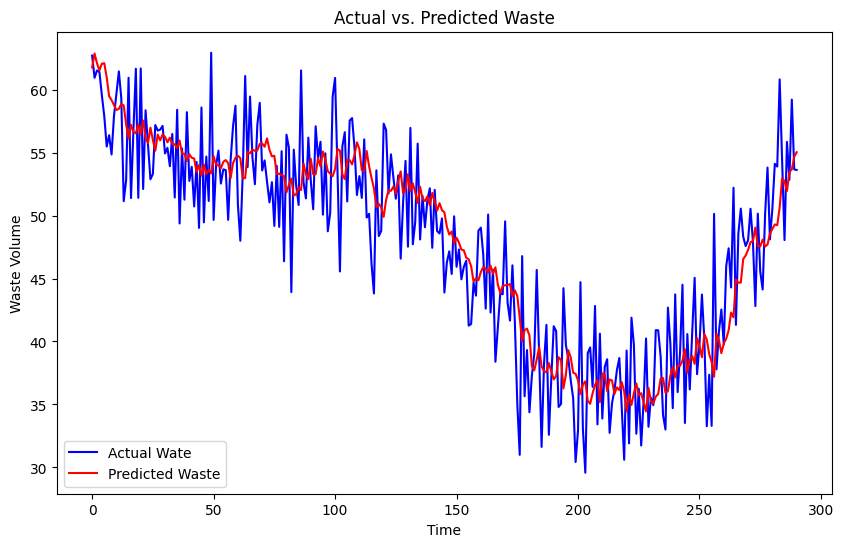

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(y_test,label='Actual Wate',color='blue')
plt.plot(predictions,label='Predicted Waste',color='red')
plt.title('Actual vs. Predicted Waste')
plt.xlabel('Time')
plt.ylabel('Waste Volume')
plt.legend()
plt.show()